# Laboratório 6 - Limiarização de Imagens

**MCZA018 – Processamento Digital de Imagens - 2026.1**

**Autores:** 

Allan Hirose Pires de Souza

Juliana dos Santos Silva

Kaike Nascimento Souza

**Data dos experimentos:** 27/03/2026

**Data de publicação:** 27/03/2026

## Introdução

Neste laboratório vamos estudar o processo de limiarização (thresholding) de imagens. A limiarização é uma técnica de segmentação que transforma uma imagem em tons de cinza em uma imagem binária, separando objetos do fundo. Vamos aplicar limiarização manual com diferentes valores de limiar e também o método automático de Otsu, que calcula o melhor limiar automaticamente. Também vamos trabalhar com a webcam aplicando limiarização em tempo real.

## Procedimentos Experimentais

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### Atividade 3.a - Limiarização manual e Otsu nas imagens dos integrantes e avatares

In [6]:
img_grupo = cv2.imread('../Files/imagem.jpeg')
img_grupo_gray = cv2.cvtColor(img_grupo, cv2.COLOR_BGR2GRAY)

avatar = cv2.imread('../Files/avatar.jpeg')
avatar_gray = cv2.cvtColor(avatar, cv2.COLOR_BGR2GRAY)

In [10]:
def aplicar_limiarizacao(img_gray, titulo, limiares=[50, 100, 127, 150, 200]):
    T_otsu, img_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_OTSU)
    
    plt.figure(figsize=(26, 4))
    plt.subplot(1, len(limiares)+3, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(1, len(limiares)+3, 2)
    plt.hist(img_gray.ravel(), bins=256, range=[0,256])
    plt.title('Histograma')
    
    for i, T in enumerate(limiares):
        _, img_bin = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY)
        plt.subplot(1, len(limiares)+3, i+3)
        plt.imshow(img_bin, cmap='gray')
        plt.title(f'T={T}')
        plt.axis('off')
    
    plt.subplot(1, len(limiares)+3, len(limiares)+3)
    plt.imshow(img_otsu, cmap='gray')
    plt.title(f'Otsu T={T_otsu:.0f}')
    plt.axis('off')
    
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()
    print(f"Limiar de Otsu para {titulo}: {T_otsu:.0f}")

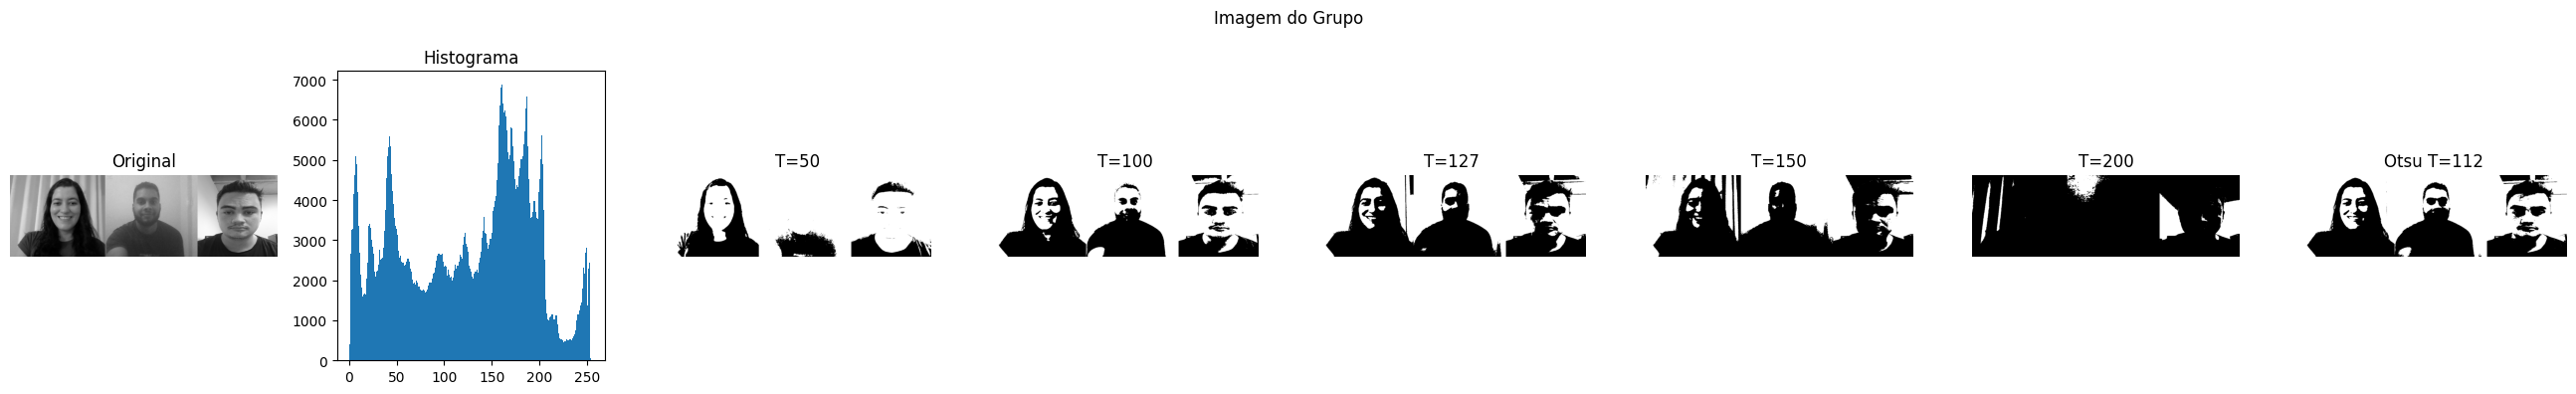

Limiar de Otsu para Imagem do Grupo: 112


In [11]:
aplicar_limiarizacao(img_grupo_gray, "Imagem do Grupo")

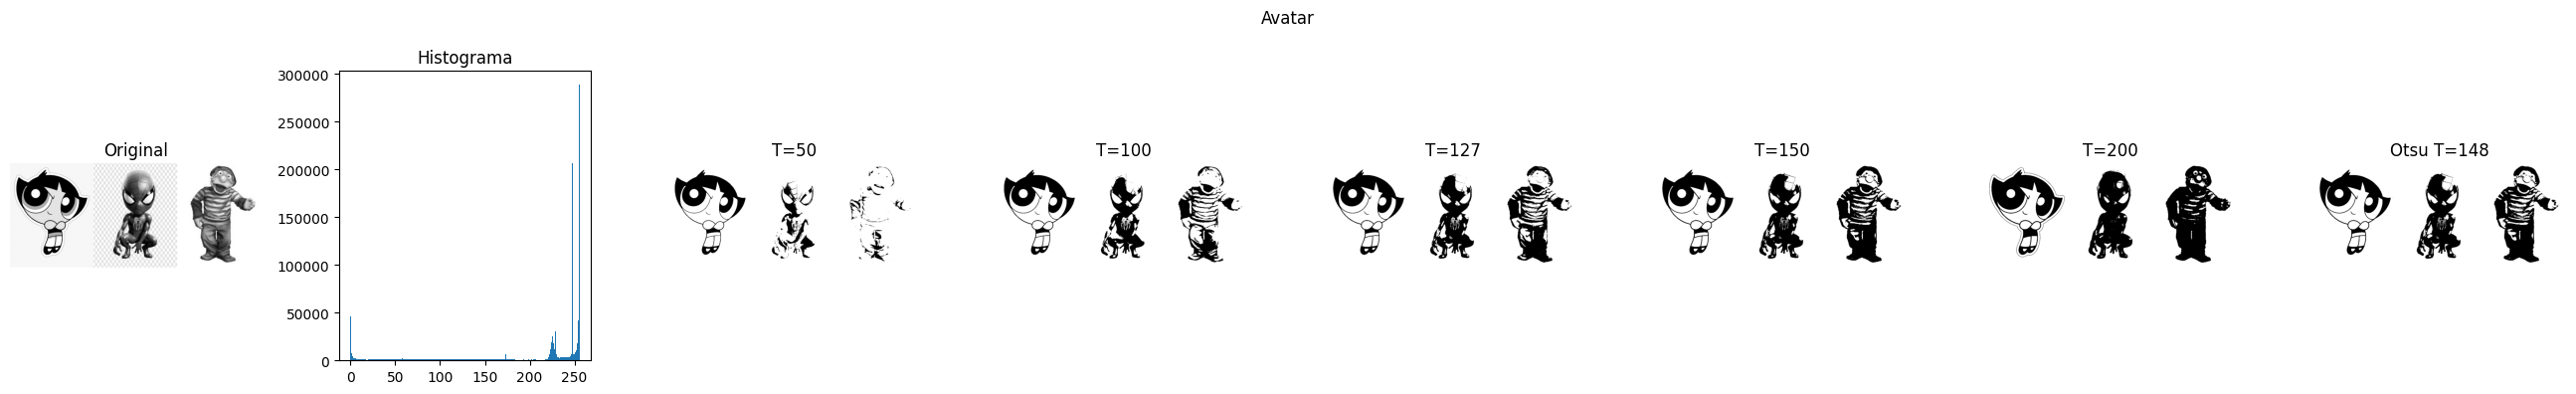

Limiar de Otsu para Avatar: 148


In [12]:
aplicar_limiarizacao(avatar_gray, "Avatar")

**Análise 3.a:**

Na imagem do grupo, com limiares muito baixos (T=50) quase tudo fica branco pois a maioria dos pixels tem intensidade acima de 50. Com limiares muito altos (T=200) quase tudo fica preto. O limiar de Otsu encontra um valor intermediário que separa melhor as regiões claras e escuras da imagem.

No avatar a mesma coisa acontece, mas como geralmente o avatar tem menos variação de tons, o Otsu consegue achar um ponto de separação mais definido. Limiares manuais muito distantes do Otsu perdem detalhes importantes ou incluem ruido demais.

De forma geral o Otsu é melhor que ficar testando manualmente porque ele calcula automaticamente o valor que maximiza a separação entre as classes de pixels.

### Atividade 3.b - Limiarização em tempo real com Webcam

O programa abaixo captura a webcam e mostra lado a lado a imagem original e a limiarizada. Pressionando 'o' ativa o Otsu e 'm' ativa o limiar manual. Com '+' e '-' ajusta o limiar manual. 'g' grava o video e 'q' sai.

In [13]:
cap = cv2.VideoCapture(0)
modo = 'otsu'
limiar_manual = 127
gravando = False
out = None

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    if modo == 'otsu':
        T, binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
        texto = f'Otsu T={T:.0f}'
    else:
        _, binaria = cv2.threshold(gray, limiar_manual, 255, cv2.THRESH_BINARY)
        texto = f'Manual T={limiar_manual}'
    
    binaria_bgr = cv2.cvtColor(binaria, cv2.COLOR_GRAY2BGR)
    cv2.putText(frame, texto, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    resultado = cv2.hconcat([frame, binaria_bgr])
    
    if gravando and out is not None:
        out.write(resultado)
    
    cv2.imshow('Limiarizacao - Webcam', resultado)
    
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('o'):
        modo = 'otsu'
    elif key == ord('m'):
        modo = 'manual'
    elif key == ord('+') or key == ord('='):
        limiar_manual = min(255, limiar_manual + 5)
    elif key == ord('-'):
        limiar_manual = max(0, limiar_manual - 5)
    elif key == ord('g'):
        if not gravando:
            h, w = resultado.shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
            out = cv2.VideoWriter('video_limiarizacao.avi', fourcc, 20.0, (w, h))
            gravando = True
            print("Gravando...")
        else:
            gravando = False
            out.release()
            out = None
            print("Gravacao finalizada.")

if out is not None:
    out.release()
cap.release()
cv2.destroyAllWindows()

**Análise 3.b:**

Na webcam o Otsu fica variando o limiar a cada frame dependendo da iluminação, o que causa uma certa "piscada" na imagem binária. Quando a iluminação é uniforme funciona bem, mas com sombras ou luz irregular ele muda bastante entre frames. 

No modo manual o limiar é fixo então a imagem é mais estável, mas se a pessoa se move pra uma area com iluminação diferente o resultado fica ruim. Artefatos comuns: sombras aparecem como objetos, reflexos de luz ficam brancos, e em areas de transição suave o contorno fica serrilhado.

### Exercício 4.a - Limiarização nas imagens do projeto final

Aplicamos a limiarização na imagem do grupo como exemplo de uso no contexto do projeto. A limiarização pode ser util para segmentar regiões de interesse, como separar pessoas do fundo.

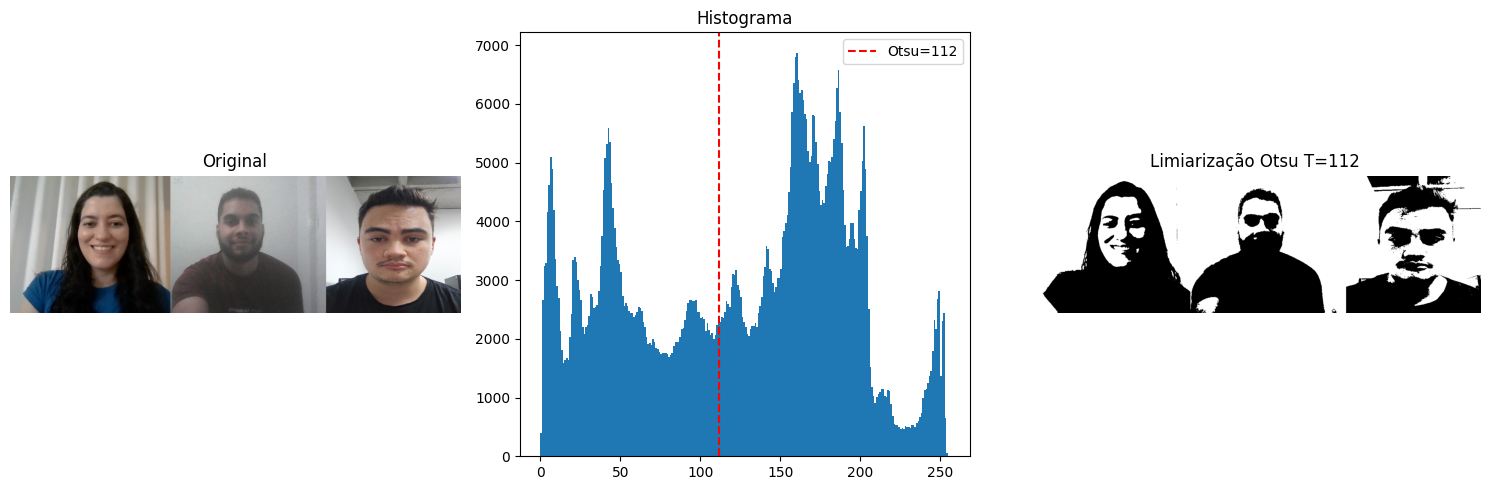

O objetivo da limiarização aqui é separar as pessoas do fundo da imagem.
O limiar de Otsu encontrado foi T=112


In [15]:
img_proj = cv2.imread('../Files/imagem.jpeg')
img_proj_gray = cv2.cvtColor(img_proj, cv2.COLOR_BGR2GRAY)

T_otsu, img_otsu = cv2.threshold(img_proj_gray, 0, 255, cv2.THRESH_OTSU)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img_proj, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(132)
plt.hist(img_proj_gray.ravel(), bins=256, range=[0,256])
plt.axvline(x=T_otsu, color='r', linestyle='--', label=f'Otsu={T_otsu:.0f}')
plt.legend()
plt.title('Histograma')

plt.subplot(133)
plt.imshow(img_otsu, cmap='gray')
plt.title(f'Limiarização Otsu T={T_otsu:.0f}')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"O objetivo da limiarização aqui é separar as pessoas do fundo da imagem.")
print(f"O limiar de Otsu encontrado foi T={T_otsu:.0f}")

## Análise e Discussão

### Questão 5.a

A inspeção visual do histograma é quando a gente olha o histograma e tenta achar um "vale" entre dois picos pra usar como limiar. Já os métodos automáticos como o Otsu calculam matematicamente qual o melhor limiar.

**Inspeção visual:**
- Vantagem: a pessoa pode usar conhecimento sobre a imagem pra escolher um bom limiar
- Desvantagem: é subjetivo, depende de quem ta olhando, e não funciona pra processar muitas imagens automaticamente

**Métodos automáticos (Otsu):**
- Vantagem: é objetivo, repetível, e funciona sem intervenção humana. Bom pra processar lotes de imagens
- Desvantagem: pode não funcionar bem quando o histograma não tem uma separação clara em dois grupos (bimodal), ou quando tem iluminação desigual na imagem

### Questão 5.b

Na img2, com T=50 (muito baixo) quase todos os pixels ficam acima do limiar, então a imagem binaria fica quase toda branca e não consegue separar os objetos do fundo direito. Com T=125 (muito alto) acontece o contrario, muitos pixels que fazem parte do objeto acabam ficando abaixo do limiar e somem.

Olhando o histograma da img2, dá pra ver que tem um vale entre os dois picos em torno de T=68-75. Esse seria o limiar mais adequado porque fica entre os dois grupos de pixels (fundo e objeto), maximizando a separação. Um valor nessa faixa consegue pegar os objetos sem incluir o fundo.

### Questão 5.c

Na imagem rice.png o método de Otsu é muito melhor que tentativa e erro porque ele acha automaticamente o limiar que melhor separa os grãos de arroz do fundo. Como os grãos são claros e o fundo é escuro, o histograma tem dois picos bem definidos e o Otsu consegue achar o vale entre eles de forma precisa.

Com tentativa e erro a gente teria que ficar testando varios valores até achar um bom, o que demora e é subjetivo. Além disso se a iluminação mudar entre imagens diferentes de arroz, o limiar manual não vai funcionar mais, enquanto o Otsu se adapta automaticamente a cada imagem.

### Exemplo com rice.png

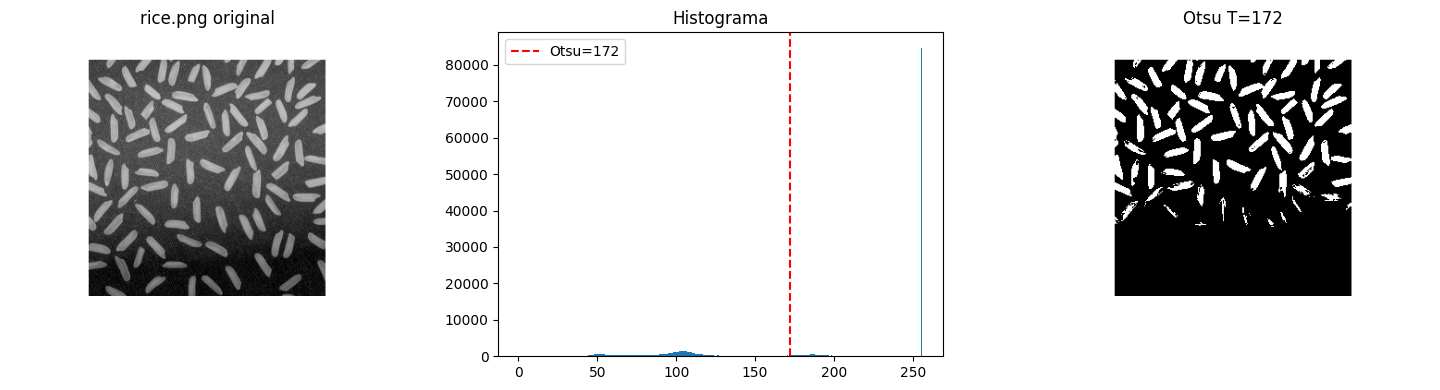

In [16]:
rice = cv2.imread('rice.png', 0)

T_otsu, rice_otsu = cv2.threshold(rice, 0, 255, cv2.THRESH_OTSU)

plt.figure(figsize=(15,4))
plt.subplot(131)
plt.imshow(rice, cmap='gray')
plt.title('rice.png original')
plt.axis('off')

plt.subplot(132)
plt.hist(rice.ravel(), bins=256, range=[0,256])
plt.axvline(x=T_otsu, color='r', linestyle='--', label=f'Otsu={T_otsu:.0f}')
plt.legend()
plt.title('Histograma')

plt.subplot(133)
plt.imshow(rice_otsu, cmap='gray')
plt.title(f'Otsu T={T_otsu:.0f}')
plt.axis('off')

plt.tight_layout()
plt.show()

## Conclusões

Neste lab aprendemos que a limiarização é uma ferramenta basica mas muito util pra segmentar imagens. O método de Otsu é bem pratico porque não precisa ficar ajustando manualmente, e funciona bem quando o histograma é bimodal. Pra imagens com iluminação desigual o Otsu pode não ser ideal e ai precisaria de métodos adaptativos. Na webcam vimos que o Otsu varia frame a frame por causa da mudança de luz, o que causa uns artefatos visuais.

## Referências

- Rafael C. Gonzalez. Digital Image Processing. 4.ed. Pearson, 2018. Chapter 9.
- Tutorial OpenCV e Python: Image Thresholding - https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
- Image Thresholding in OpenCV. Satya Mallick - https://learnopencv.com/opencv-threshold-python-cpp/